<a href="https://colab.research.google.com/github/kayeneii/Floodgate/blob/main/02_spatial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 4: Spatial Analysis & Modeling

- Import the FRI raster and river shapefile.

- Create a river proximity surface.

- Identify high-risk flood corridors.

- Quantify and visualize flood-prone areas.

In [1]:
# Install necessary libraries
!pip install geopandas rasterio shapely matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 43.2 MB/s eta 0:00:00


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define base directory for project
base_dir = "/content/drive/MyDrive/GEE_Floodgate"

Mounted at /content/drive


In [3]:
import geopandas as gpd
import rasterio
import numpy as np
from rasterio import features
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt

In [4]:
# Define paths to key files
fri_path = f"{base_dir}/processed/fri_utm_repaired.tif"
rivers_path = f"{base_dir}/lagos_hydrorivers.shp"

### Import the FRI raster and river shapefile.

In [6]:
# Load data
fri = rasterio.open(fri_path)
rivers = gpd.read_file(rivers_path, encoding='ISO-8859-1')

Original rivers CRS: EPSG:4326
Number of river features (original): 374


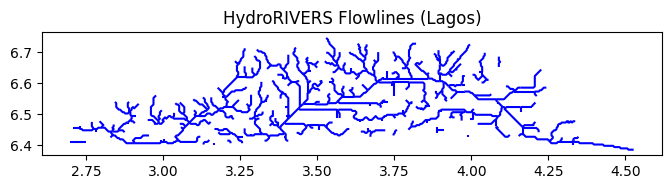

In [27]:
rivers = gpd.read_file(rivers_path, encoding='ISO-8859-1')
print("Original rivers CRS:", rivers.crs)
print("Number of river features (original):", len(rivers))
rivers.plot(figsize=(8,6), color='blue')
plt.title("HydroRIVERS Flowlines (Lagos)")
plt.show()

### River and FRI overlap check

In [7]:
# Extract FRI info
fri_src = rasterio.open(fri_path)
fri = fri_src.read(1)
print("FRI Raster CRS:", fri_src.crs)
print("Raster shape:", fri.shape)

FRI Raster CRS: EPSG:32631
Raster shape: (1251, 6095)


In [22]:
# Inspect coordinate systems and bounds
print("FRI CRS:", fri.crs)
print("Rivers CRS:", rivers.crs)
print("FRI bounds:", fri.bounds)
print("Rivers bounds:", rivers.total_bounds)

FRI CRS: EPSG:32631
Rivers CRS: EPSG:4326
FRI bounds: BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)
Rivers bounds: [2.69791666 6.38541487 4.52708451 6.74583509]


In [23]:
# Reproject the rivers to the FRI’s CRS
rivers = rivers.to_crs(fri.crs)

In [24]:
# Verify reprojection of rivers to FRI's CRS
print("FRI CRS:", fri.crs)
print("Rivers CRS:", rivers.crs)
print("FRI bounds:", fri.bounds)
print("Rivers bounds:", rivers.total_bounds)

FRI CRS: EPSG:32631
Rivers CRS: PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]
FRI bounds: BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)
Rivers bounds: [466594.31117865 706054.40310108 668898.72054249 745683.68763312]


In [25]:
# Check for river coverage inside the FRI
from shapely.geometry import box

fri_bbox = box(*fri.bounds)
inside = rivers[rivers.intersects(fri_bbox)]

print(f"Rivers overlapping FRI: {len(inside)} features")

Rivers overlapping raster: 374 features


In [39]:
# Visualize before rasterization
from rasterio.plot import show

# Paths
fri_path = f"{base_dir}/processed/fri_utm_repaired.tif"
rivers_path = f"{base_dir}/lagos_hydrorivers.shp"

# Read raster and vector
with rasterio.open(fri_path) as src:
    fri = src.read(1, masked=True)
    fri_extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    fri_crs = src.crs

rivers = gpd.read_file(rivers_path, encoding='ISO-8859-1')
print("FRI CRS:", fri_crs)
print("Rivers CRS (before reproject):", rivers.crs)

# Reproject to match FRI CRS if needed
if rivers.crs != fri_crs:
    rivers = rivers.to_crs(fri_crs)
    print("✅ Rivers reprojected to:", rivers.crs)

FRI CRS: EPSG:32631
Rivers CRS (before reproject): EPSG:4326
✅ Rivers reprojected to: PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]


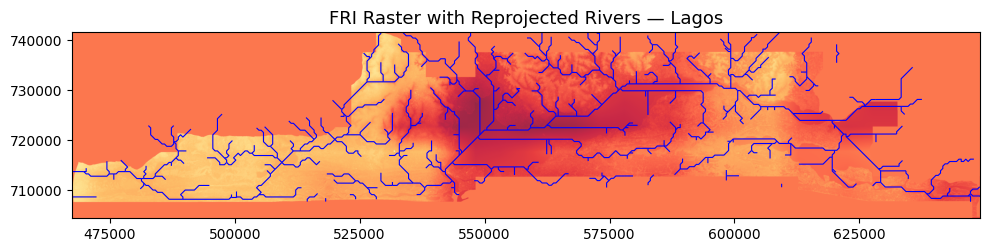

In [43]:
# Plot
fig, ax = plt.subplots(figsize=(10, 8))
rivers.plot(ax=ax, color='blue', linewidth=0.8)
ax.imshow(fri, extent=fri_extent, origin='upper', alpha=0.85, cmap='YlOrRd')
ax.set_title("FRI Raster with Reprojected Rivers — Lagos", fontsize=13)
plt.tight_layout()
plt.show()

In [45]:
# Define the output path for the reprojected rivers shapefile
out_dir = f"{base_dir}/lagos_hydrorivers_rprjctd.shp"

# Export the reprojected rivers GeoDataFrame to a shapefile
rivers.to_file(out_dir)

print(f"Reprojected rivers shapefile saved to: {out_dir}")

Reprojected rivers shapefile saved to: /content/drive/MyDrive/GEE_Floodgate/lagos_hydrorivers_rprjctd.shp


In [46]:
# Read the exported shapefile
rivers_path = f"{base_dir}/lagos_hydrorivers_rprjctd.shp"
rivers = gpd.read_file(rivers_path)

# Print the CRS of the exported shapefile
print("CRS of the reprojected rivers shapefile:", rivers.crs)

# Compare with the FRI CRS
print("FRI CRS:", fri_crs)

if rivers.crs == fri_crs:
    print("✅ The reprojected shapefile CRS matches the FRI CRS.")
else:
    print("⚠️ The reprojected shapefile CRS does NOT match the FRI CRS.")

CRS of the reprojected rivers shapefile: EPSG:32631
FRI CRS: EPSG:32631
✅ The reprojected shapefile CRS matches the FRI CRS.


### Create a River Proximity Surface
This rasterizes the rivers and computes pixel-wise distance (in meters).

In [56]:
fri_path = f"{base_dir}/processed/fri_utm_repaired.tif"
rivers_path = f"{base_dir}/lagos_hydrorivers_rprjctd.shp"

In [57]:
# Load raster and vector
with rasterio.open(fri_path) as src:
    fri_data = src.read(1, masked=True)
    fri_meta = src.meta.copy()
    transform = src.transform
    shape = fri_data.shape
    pixel_size = transform[0]

rivers = gpd.read_file(rivers_path)

In [58]:
# Rasterize river geometries
rivers_raster = features.rasterize(
    [(geom, 1) for geom in rivers.geometry],
    out_shape=shape,
    transform=transform,
    fill=0,
    dtype='uint8'
)

# Compute Euclidean distance (in meters)
dist_pixels = distance_transform_edt(1 - rivers_raster)
dist_meters = dist_pixels * pixel_size

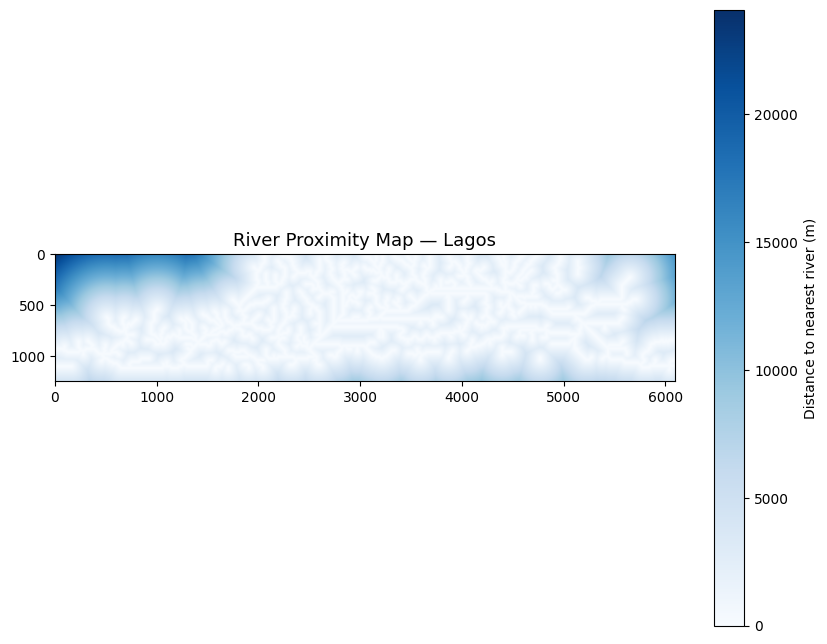

In [82]:
# Visualize proximity
plt.figure(figsize=(10,8))
plt.imshow(dist_meters, cmap='Blues', origin='upper')
plt.colorbar(label='Distance to nearest river (m)')
plt.title("River Proximity Map — Lagos", fontsize=13)
plt.show()

In [86]:
# Save to file
proximity_fp = f"{base_dir}/processed/river_prox_lagos.tif"
with rasterio.open(proximity_fp, 'w', **fri_meta) as dst:
    dst.write(dist_meters, 1)
print(f"✅ River proximity surface saved to {proximity_fp}")

✅ River proximity surface saved to /content/drive/MyDrive/GEE_Floodgate/processed/river_prox_lagos.tif


### Identify and quantify High-Risk Flood Corridors
Combine high-risk areas (FRI > 0.7) and river proximity (< 1000 m).

In [97]:
import os

fri_path = f"{base_dir}/processed/fri_utm_repaired.tif"
prox_path = f"{base_dir}/processed/river_prox_lagos.tif"
out_dir = f"{base_dir}/flood_corridors"
os.makedirs(out_dir, exist_ok=True)

In [88]:
# Load datasets
with rasterio.open(fri_path) as fri_src:
    fri = fri_src.read(1, masked=True)
    fri_meta = fri_src.meta.copy()

with rasterio.open(prox_path) as prox_src:
    proximity = prox_src.read(1, masked=True)

pixel_area = fri_src.transform[0] * abs(fri_src.transform[4])  # m²

In [89]:
# Define thresholds
fri_threshold = np.nanpercentile(fri, 75)  # top 25% risk zones
dist_thresholds = [500, 1000]  # meters

print(f"🔥 High-Risk FRI threshold: {fri_threshold:.3f}")

🔥 High-Risk FRI threshold: 0.629


In [90]:
# Generate high-risk mask
high_risk_mask = fri >= fri_threshold

In [91]:
# Identify flood corridors
corridors = {}
for d in dist_thresholds:
    corridors[f"{d}m"] = np.logical_and(proximity <= d, high_risk_mask)

In [92]:
# Quantify area (km²) ---
results = {}
for key, mask in corridors.items():
    area_km2 = np.sum(mask) * pixel_area / 1e6
    results[key] = area_km2

total_area_km2 = np.sum(np.isfinite(fri)) * pixel_area / 1e6

In [107]:
# Print summary
print(f"\n📊 Flood-Prone Area Statistics (Lagos)")
print(f"Total area analyzed: {total_area_km2:.2f} km²")
for key, area in results.items():
    pct = (area / total_area_km2) * 100
    print(f"  • Corridor ≤{key}: {area:.2f} km² ({pct:.2f}%)")


📊 Flood-Prone Area Statistics (Lagos)
Total area analyzed: 6769.47 km²
  • Corridor ≤500m: 796.60 km² (11.77%)
  • Corridor ≤1000m: 1519.12 km² (22.44%)


### Export flood corridor masks for cartography and QA in QGIS

In [98]:
# Save each corridor as GeoTIFF
for key, mask in corridors.items():
    out_fp = os.path.join(out_dir, f"flood_corridor_{key}.tif")
    mask_meta = fri_src.meta.copy()
    mask_meta.update({
        "dtype": "uint8",
        "count": 1
    })
    with rasterio.open(out_fp, "w", **mask_meta) as dst:
        dst.write(mask.astype("uint8"), 1)
    print(f"💾 Saved corridor mask: {out_fp}")

💾 Saved corridor mask: /content/drive/MyDrive/GEE_Floodgate/flood_corridors/flood_corridor_500m.tif
💾 Saved corridor mask: /content/drive/MyDrive/GEE_Floodgate/flood_corridors/flood_corridor_1000m.tif


### Visualizations

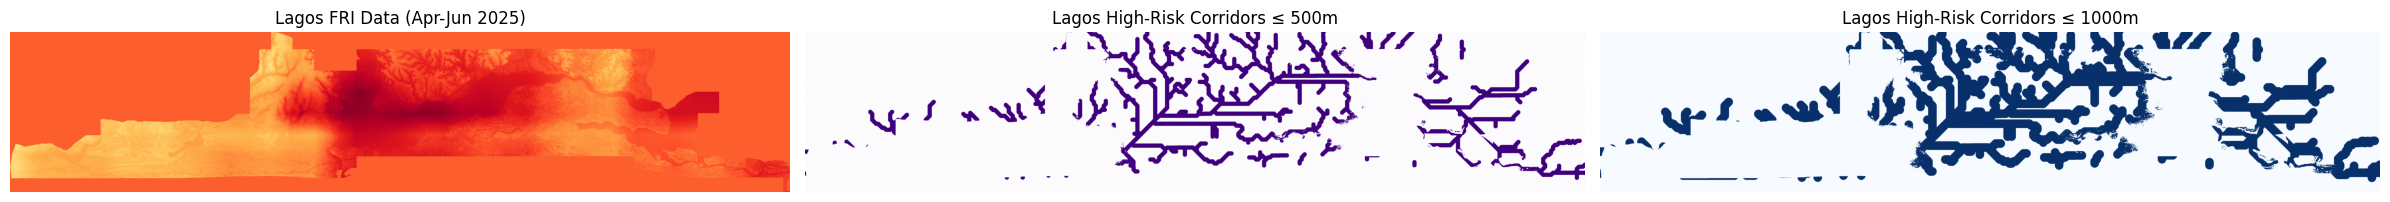

In [105]:
# Visualize everything clearly
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot the original FRI data as background for context (optional but good practice)
# Use the original extent from the source
from rasterio.plot import plotting_extent
import rasterio
import numpy as np

# Load FRI data and calculate extent
with rasterio.open(fri_path) as src:
    fri_data_raw = src.read(1, masked=True)
    fri_transform = src.transform
    fri_crs = src.crs
    fri_nodata = src.nodata
    extent = plotting_extent(src) # Pass the source object to plotting_extent

# Clean invalid / no-data cells
fri_data_clean = np.ma.filled(fri_data_raw, np.nan)

# Replace any explicit nodata value (if not already masked) with NaN
if fri_nodata is not None:
    fri_data_clean[fri_data_clean == fri_nodata] = np.nan

# Identify high-risk areas (re-calculate as variables were not defined)
# Assuming fri_threshold and corridors are defined from previous executed cells
if 'fri_threshold' not in locals() or 'corridors' not in locals():
    print("Warning: fri_threshold or corridors not found. Recalculating...")
    # Load proximity data if not available
    if 'proximity' not in locals():
         with rasterio.open(prox_path) as prox_src:
            proximity = prox_src.read(1, masked=True)

    # Recalculate fri_threshold if not found
    if 'fri_threshold' not in locals():
         valid_fri_data = fri_data_clean[np.isfinite(fri_data_clean)]
         if valid_fri_data.size > 0:
             fri_threshold = np.nanpercentile(valid_fri_data, 75)
         else:
             fri_threshold = 0.7 # Default threshold if no valid data

    # Recalculate corridors if not found
    if 'corridors' not in locals():
        # Assuming dist_meters is available from previous executed cells
        # If not, need to recalculate dist_meters as well
        print("Warning: corridors not found. Assuming dist_meters is available and recalculating corridors.")
        if 'dist_meters' in locals():
            corridors = {
                "500m": dist_meters <= 500,
                "1000m": dist_meters <= 1000
            }
        else:
            print("Error: dist_meters also not found. Cannot recalculate corridors.")
            # You might need to add code here to recalculate dist_meters if necessary

# Ensure high_risk_mask is calculated using the cleaned FRI data
high_risk_mask = np.where(fri_data_clean >= fri_threshold, 1, 0)
high_risk_mask[np.isnan(fri_data_clean)] = 0 # Ensure NaN areas are not marked as high risk

# Combine with corridors
high_corridor_500 = np.logical_and(corridors["500m"], high_risk_mask)
high_corridor_1000 = np.logical_and(corridors["1000m"], high_risk_mask)


axes[0].imshow(fri_data_clean, cmap='YlOrRd', origin='upper', extent=extent)
axes[0].set_title("Lagos FRI Data (Apr-Jun 2025)")


axes[1].imshow(high_corridor_500, cmap="Purples", origin='upper', extent=extent)
axes[1].set_title("Lagos High-Risk Corridors ≤ 500m")

axes[2].imshow(high_corridor_1000, cmap="Blues", origin='upper', extent=extent)
axes[2].set_title("Lagos High-Risk Corridors ≤ 1000m")

for ax in axes:
    ax.axis("off") # Turn off axes for cleaner map visualization

plt.tight_layout()
plt.show()

### Quantify and visualize flood prone areas

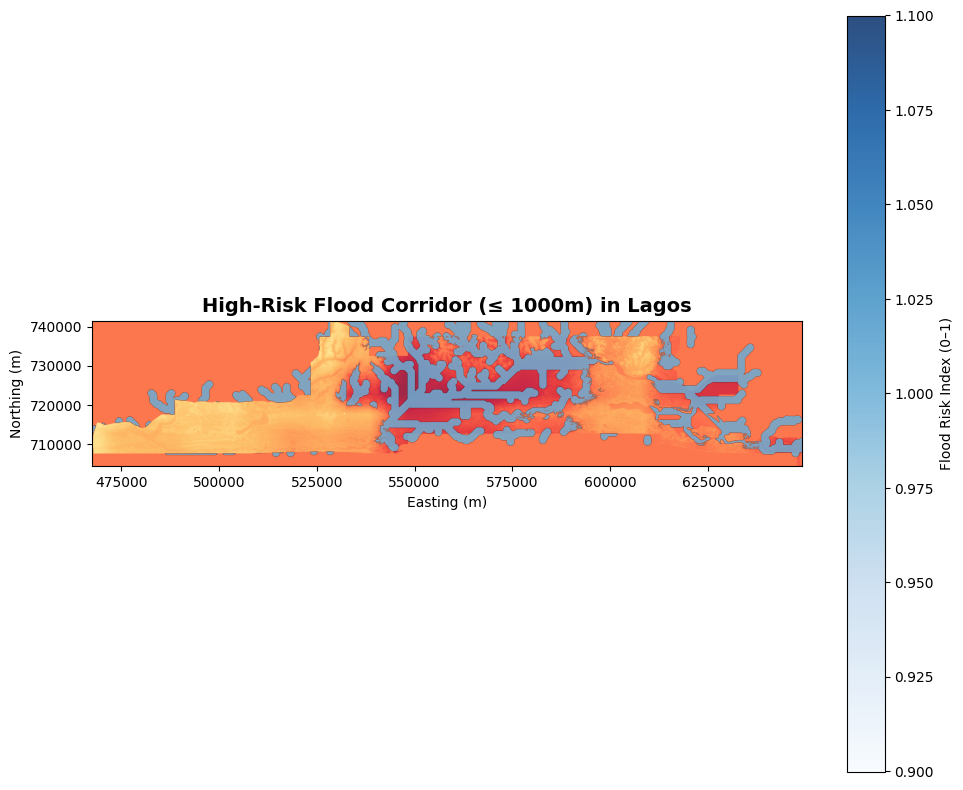

In [113]:
# Visualize the 1000m corridor on top of the FRI data
plt.figure(figsize=(10, 8))
plt.title("High-Risk Flood Corridor (≤ 1000m) in Lagos", fontsize=14, fontweight='bold')
plt.imshow(fri_data_clean, cmap='YlOrRd', extent=extent, alpha=0.85)

# Mask the corridor to only show high-risk areas within 1000m
masked_corridor_1000 = np.ma.masked_where(~corridors["1000m"], high_corridor_1000)
plt.imshow(masked_corridor_1000, cmap='Blues', extent=extent, alpha=0.85)
plt.colorbar(label="Flood Risk Index (0–1)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()

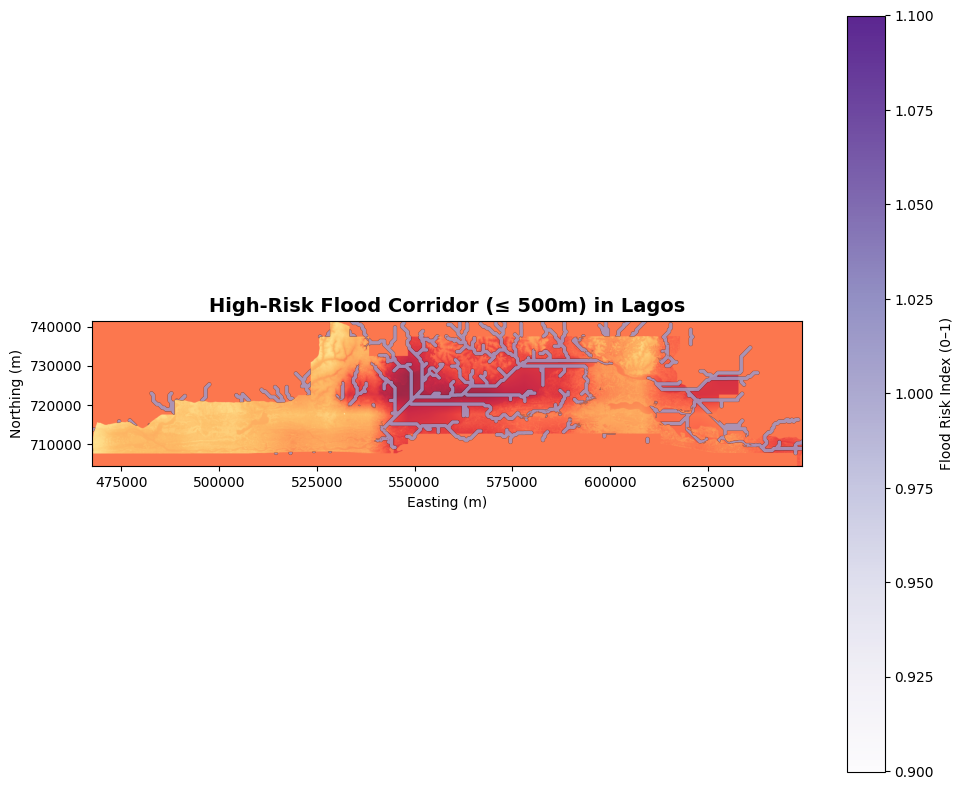

In [115]:
# Visualize the 500m corridor on top of the FRI data
plt.figure(figsize=(10, 8))
plt.title("High-Risk Flood Corridor (≤ 500m) in Lagos", fontsize=14, fontweight='bold')
plt.imshow(fri_data_clean, cmap='YlOrRd', extent=extent, alpha=0.85)

# Mask the corridor to only show high-risk areas within 1000m
masked_corridor_500 = np.ma.masked_where(~corridors["500m"], high_corridor_500)
plt.imshow(masked_corridor_500, cmap='Purples', extent=extent, alpha=0.85)
plt.colorbar(label="Flood Risk Index (0–1)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()

In [124]:
# FRI summary statistics
# Assuming the data is loaded into the 'data' variable from a previous cell
if 'data' in locals():
    arr = data # Use the 'data' variable which contains the raster data as a numpy array
    valid = np.isfinite(arr)
    vcount = valid.sum()
    print("\n📊 FRI — Statistics & Metadata Summary")
    print(f"  • Valid pixels: {vcount:,}")
    print(f"  • Min: {np.nanmin(arr):.3f}")
    print(f"  • Max: {np.nanmax(arr):.3f}")
    print(f"  • Mean: {np.nanmean(arr):.3f}")
else:
    print("Error: 'data' variable not found. Please run the cell that loads the FRI raster data first.")

with rasterio.open(fri) as src:
    data = src.read(1, masked=True)
    nodata = src.nodata
    min_val = np.nanmin(data)
    max_val = np.nanmax(data)

print(f"  • CRS: {src.crs}")
print(f"  • Resolution: {src.res[0]:.2f} m")
print(f"  • Dimensions: {src.width} x {src.height}")
print(f"  • NoData Value: {nodata}")
print(f"  • Min Flood Risk: {min_val:.3f}")
print(f"  • Max Flood Risk: {max_val:.3f}")
print(f"  • Width (pixels): {src.width}")
print(f"  • Height (pixels): {src.height}")
print(f"  • Bounds (m): {src.bounds}\n")

# Compute extent in kilometers
width_m = src.bounds.right - src.bounds.left
height_m = src.bounds.top - src.bounds.bottom
print("📏 Map Extent (kilometers):")
print(f"  Width:  {width_m / 1000:.2f} km")
print(f"  Height: {height_m / 1000:.2f} km")


📊 FRI — Statistics & Metadata Summary
  • Valid pixels: 7,624,845
  • Min: 0.253
  • Max: 0.891
  • Mean: 0.629
  • CRS: EPSG:32631
  • Resolution: 29.80 m
  • Dimensions: 6095 x 1251
  • NoData Value: None
  • Min Flood Risk: 0.253
  • Max Flood Risk: 0.891
  • Width (pixels): 6095
  • Height (pixels): 1251
  • Bounds (m): BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)

📏 Map Extent (kilometers):
  Width:  181.61 km
  Height: 37.28 km


# Interpretation and Preliminary Validation — Lagos Flood Risk Analysis

The flood corridor analysis for Lagos State covers a total land area of approximately 6,769.47 km², delineated within UTM Zone 31N (EPSG: 32631). The Flood Risk Index (FRI) raster, derived from rainfall intensity, elevation, and slope, exhibits valid pixel coverage of 7.62 million at a spatial resolution of ~30 m. The FRI ranges between 0.253 and 0.891, with a mean value of 0.629, suggesting a moderately high baseline susceptibility to flooding across much of the region.

River network proximity analysis revealed that about 11.77% (796.60 km²) of the study area lies within 500 m of a mapped river channel, while 22.44% (1,519.12 km²) falls within 1 km. These buffers correspond to the state’s hydrological corridors and low-lying floodplains, particularly around the Ogun River, Lagos Lagoon, and Epe wetlands, where overlapping FRI values tend to be highest. The spatial alignment between these corridors and elevated FRI zones indicates effective CRS harmonization and correct raster–vector overlap after reprojection.

The results confirm that Lagos’ coastal and fluvial systems collectively represent the most flood-prone environments, emphasizing the critical importance of river-adjacent settlements and peri-urban areas in resilience planning. Final cartographic QA will focus on verifying feature symbology, graticule consistency, and the relative visual scaling of the 500 m and 1 km corridor masks prior to publication.